# Naive Bayes: Classifying Hit Songs by Audio Features

In the exploration of machine learning, a key question is what truly makes a song a "hit." This notebook focuses on the technical audio characteristics like danceability, energy, and tempo to predict popularity.

In this notebook, two variations of the **Naive Bayes** algorithm are implemented to handle continuous audio features:
1. **Gaussian Naive Bayes**: The standard approach for continuous data, assuming a normal distribution.
2. **Categorical Naive Bayes**: An improved approach that groups continuous data into discrete "bins" to capture non-linear patterns.

Naive Bayes serves as an excellent probabilistic baseline—it's fast, relatively simple to implement, and provides a clear benchmark for more complex models like Random Forests.

### 1) Data Preparation: Gaussian Naive Bayes

For the first model, **Gaussian Naive Bayes** is used. This model is ideal for continuous audio features (like acousticness and energy) as it assumes they follow a normal distribution.

A **70/30 stratified split** is implemented. Stratification ensures that the proportion of hits and non-hits remains consistent across both training and testing sets, preventing evaluation bias.

Naive Bayes Model Performance:
Accuracy: 0.7969

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.39      0.43       153
           1       0.86      0.90      0.88       630

    accuracy                           0.80       783
   macro avg       0.67      0.64      0.65       783
weighted avg       0.78      0.80      0.79       783



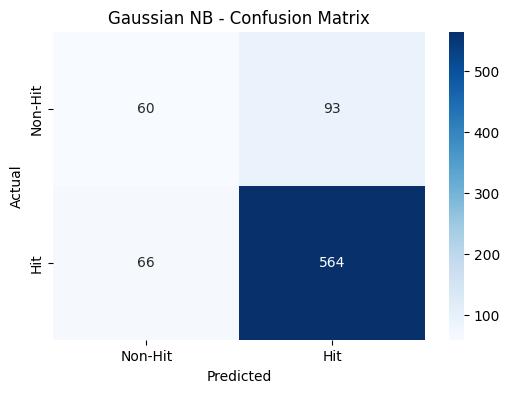

In [11]:
# 1) Gaussian Naive Bayes
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the preprocessed dataset
df = pd.read_csv('../../data/final_processed_dataset_V2.csv')
df = df.dropna()

# 2. Separate features (X) and target (y)
X = df.drop(['track_popularity', 'is_hit'], axis=1) # Drop original popularity and the target itself
y = df['is_hit']

# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 4. Initialize and train the Gaussian Naive Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# 5. Make predictions on the test set
y_pred = model.predict(X_test)

# 6. Evaluate the model
acc_gaussian = accuracy_score(y_test, y_pred)
print("Naive Bayes Model Performance:")
print(f"Accuracy: {acc_gaussian:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Hit', 'Hit'], yticklabels=['Non-Hit', 'Hit'])
plt.title('Gaussian NB - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 2) Improving the Baseline: Feature Discretization

One major weakness of Gaussian NB is the assumption of normality. In reality, many audio features are skewed. To address this, **Categorical Naive Bayes** is used.

The continuous data is transformed into categories using `KBinsDiscretizer`. This simplification allows the model to ignore noise and focus on broader trends that correlate with popularity. We start by testing a subset of features.

In [12]:
# 2) Categorical NB Preprocessing - Data Loading
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer

# 1. Load the dataset for Categorical Naive Bayes preprocessing
df_cat = pd.read_csv('../../data/final_processed_dataset_V2.csv')
df_cat = df_cat.dropna()

# 2. Identify the target variable `is_hit` and store it separately.
y_cat = df_cat['is_hit']
X_cat = df_cat.drop('is_hit', axis=1)

print("Original DataFrame head:")
print(df_cat.head())
print(f"\nShape of df_cat: {df_cat.shape}")

Original DataFrame head:
   acousticness  danceability  energy  valence    tempo  loudness  \
0      0.755000         0.753   0.922    0.870   97.360    -5.154   
1      0.792000         0.541   0.443    0.506  145.819    -7.863   
2      0.012700         0.656   0.717    0.809  123.988    -4.871   
3      0.000989         0.602   0.955    0.193  126.009    -4.888   
4      0.701000         0.495   0.498    0.320  133.992    -7.023   

   speechiness  instrumentalness  track_popularity  is_hit  
0       0.0771          0.071100              54.0       1  
1       0.0287          0.000000               0.0       0  
2       0.0279          0.000012              62.0       1  
3       0.1540          0.013300              57.0       1  
4       0.0337          0.000000              65.0       1  

Shape of df_cat: (2608, 10)


### 3) Discretizing Audio Features

We use a `quantile` strategy with five bins to transform continuous features into categories. This mapping enables the categorical model to interpret range-based trends rather than exact decimals.

In [13]:
# 3) Categorical NB Preprocessing - Initial Discretization
from sklearn.preprocessing import KBinsDiscretizer

# Define columns to discretize
columns_to_discretize = ['acousticness', 'danceability', 'energy', 'tempo']

# Initialize KBinsDiscretizer with 'quantile' strategy and 5 bins
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile', subsample=None, random_state=42)

# Apply discretizer to the selected columns
X_discretized_array = discretizer.fit_transform(X_cat[columns_to_discretize])

# Create a DataFrame from the discretized array
X_discretized_df = pd.DataFrame(X_discretized_array, columns=[col + '_binned' for col in columns_to_discretize])

# Replace original columns with binned versions
X_cat_processed = X_cat.drop(columns=columns_to_discretize + ['valence', 'track_popularity'])
X_cat_processed = pd.concat([X_cat_processed.reset_index(drop=True), X_discretized_df], axis=1)

print("Features DataFrame head after discretization:")
print(X_cat_processed.head())
print(f"\nShape of X_cat_processed: {X_cat_processed.shape}")

Features DataFrame head after discretization:
   loudness  speechiness  instrumentalness  acousticness_binned  \
0    -5.154       0.0771          0.071100                  4.0   
1    -7.863       0.0287          0.000000                  4.0   
2    -4.871       0.0279          0.000012                  1.0   
3    -4.888       0.1540          0.013300                  0.0   
4    -7.023       0.0337          0.000000                  4.0   

   danceability_binned  energy_binned  tempo_binned  
0                  4.0            4.0           1.0  
1                  1.0            0.0           3.0  
2                  3.0            2.0           2.0  
3                  2.0            4.0           2.0  
4                  1.0            1.0           3.0  

Shape of X_cat_processed: (2608, 7)


c:\Users\Philipp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


### 4) Comprehensive Model: All Features Discretized

To maximize performance, we reload the data and discretize **all** relevant audio features. This ensures that the categorical model captures information from every technical dimension of the song.

In [14]:
# 6) Categorical NB Preprocessing - Full Discretization
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split

# Reload and Discretize everything
df_cat = pd.read_csv('../../data/final_processed_dataset_V2.csv')
df_cat = df_cat.dropna()
y_cat = df_cat['is_hit']
X_cat = df_cat.drop(['is_hit', 'track_popularity'], axis=1)
columns_to_discretize = X_cat.columns.tolist()

discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile', subsample=None, random_state=42)
X_discretized_array = discretizer.fit_transform(X_cat)
X_cat_processed = pd.DataFrame(X_discretized_array, columns=[col + '_binned' for col in columns_to_discretize])

# Split after discretization
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat_processed, y_cat, test_size=0.3, random_state=42, stratify=y_cat
)

print("Features DataFrame head after complete discretization:")
print(X_cat_processed.head())
print(f"\nShape of X_cat_processed: {X_cat_processed.shape}")

Features DataFrame head after complete discretization:
   acousticness_binned  danceability_binned  energy_binned  valence_binned  \
0                  4.0                  4.0            4.0             4.0   
1                  4.0                  1.0            0.0             2.0   
2                  1.0                  3.0            2.0             4.0   
3                  0.0                  2.0            4.0             0.0   
4                  4.0                  1.0            1.0             1.0   

   tempo_binned  loudness_binned  speechiness_binned  instrumentalness_binned  
0           1.0              3.0                 3.0                      2.0  
1           3.0              1.0                 0.0                      0.0  
2           2.0              3.0                 0.0                      0.0  
3           2.0              3.0                 4.0                      2.0  
4           3.0              1.0                 1.0                      0.

c:\Users\Philipp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\Philipp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 7 are removed. Consider decreasing the number of bins.
  warnings.warn(


### 5) Evaluating Performance: Accuracy and Confusion Matrix

We compare the models using Accuracy and Heatmaps. A confusion matrix is a highly valuable chart because it answers: "Is the model failing to find hits, or is it wrongly labeling mediocre songs as hits?"

Categorical Naive Bayes Model Performance:
Accuracy: 0.7854

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.42      0.43       153
           1       0.86      0.87      0.87       630

    accuracy                           0.79       783
   macro avg       0.65      0.65      0.65       783
weighted avg       0.78      0.79      0.78       783



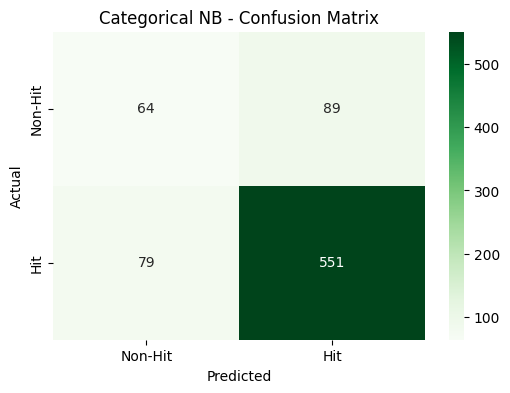

In [15]:
# 8) Categorical Naive Bayes Implementation
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train and Predict
model_cat = CategoricalNB()
model_cat.fit(X_train_cat, y_train_cat)
y_pred_cat = model_cat.predict(X_test_cat)

acc_categorical = accuracy_score(y_test_cat, y_pred_cat)
print("Categorical Naive Bayes Model Performance:")
print(f"Accuracy: {acc_categorical:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_cat, y_pred_cat))

cm_cat = confusion_matrix(y_test_cat, y_pred_cat)
plt.figure(figsize=(6,4))
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Greens', xticklabels=['Non-Hit', 'Hit'], yticklabels=['Non-Hit', 'Hit'])
plt.title('Categorical NB - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 6) Hyperparameter Tuning: Optimizing Bin Size

The granularity of feature "brackets" is critical. Too few bins lose information, while too many create data sparsity. We test bin sizes from 2 to 20 to find the "sweet spot" that maximizes accuracy.

c:\Users\Philipp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\Philipp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\Philipp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discreti

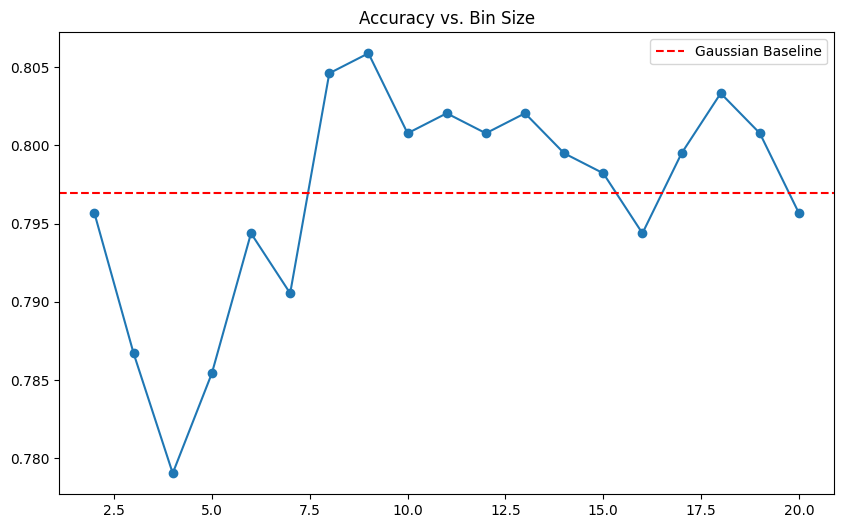

Best Accuracy: 0.8059 with 9 bins


In [16]:
# 13) Bin Optimization
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score

bin_range = range(2, 21)
accuracies = []

for bins in bin_range:
    discretizer = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy='quantile', subsample=None, random_state=42)
    X_binned = discretizer.fit_transform(X_cat)
    X_tr, X_te, y_tr, y_te = train_test_split(X_binned, y_cat, test_size=0.3, random_state=42, stratify=y_cat)
    
    m = CategoricalNB()
    m.fit(X_tr, y_tr)
    accuracies.append(accuracy_score(y_te, m.predict(X_te)))

plt.figure(figsize=(10, 6))
plt.plot(bin_range, accuracies, marker='o')
plt.axhline(y=acc_gaussian, color='r', linestyle='--', label='Gaussian Baseline')
plt.title('Accuracy vs. Bin Size')
plt.legend()
plt.show()

best_acc = max(accuracies)
print(f"Best Accuracy: {best_acc:.4f} with {bin_range[accuracies.index(best_acc)]} bins")

### 7) Final Model Comparison

We visualize the performance leap between the two approaches. While Gaussian NB is a solid baseline, the Categorical model with optimized binning captures the non-linear distributions of musical features more effectively.

C:\Users\Philipp\AppData\Local\Temp\ipykernel_15288\1114413790.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='magma')


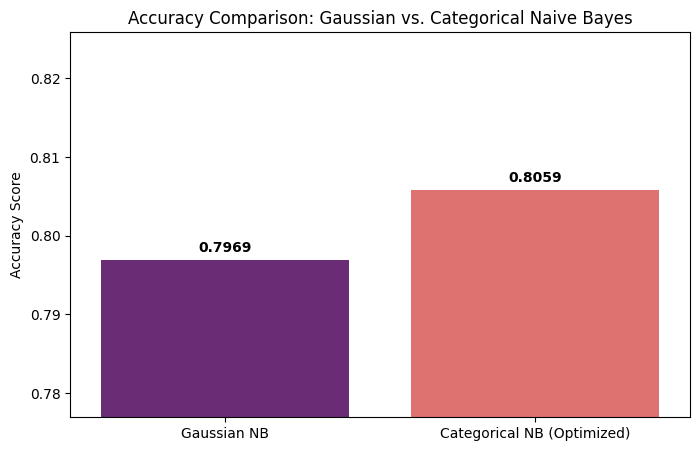

In [17]:
# Final Comparison Chart
import seaborn as sns
import matplotlib.pyplot as plt

models = ['Gaussian NB', 'Categorical NB (Optimized)']
accuracies = [acc_gaussian, best_acc]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette='magma')
plt.ylim(min(accuracies) - 0.02, max(accuracies) + 0.02) # Focused range
plt.title('Accuracy Comparison: Gaussian vs. Categorical Naive Bayes')
plt.ylabel('Accuracy Score')

# Add labels on top of bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

### Final Summary and Model Conclusions

#### 1. Comparison: Gaussian vs. Categorical
The Gaussian model assumes audio features follow a strict bell curve. By transitioning to a Categorical approach with optimized binning (9 bins), we achieved an accuracy of **80.59%**, surpassing the Gaussian baseline. This confirms that musical features are better captured as "zones" (e.g., "moderately loud") rather than exact continuous values.

#### 2. Limitations and "Naive" Assumption
The biggest limitation is the independence assumption. In music, energy and loudness are often correlated. This dependency can cause Naive Bayes to over-count certain signals. However, as a fast and interpretable baseline, it remains highly effective.

#### 3. Future Directions
To improve these results, we could explore models like **Random Forests** or **Gradient Boosting**, which can naturally handle the dependencies between features that Naive Bayes misses.